In [1]:
import pandas as pd
import numpy as np

returns = pd.read_csv(
    "../data/processed/returns.csv",
    index_col=0,
    parse_dates=True
)

returns.head()

,AAPL,AMGN,AMZN,AXP,BA,CAT,CRM,CSCO,CVX,DIS,...,MRK,MSFT,NKE,NVDA,PG,SHW,TRV,UNH,V,WMT
date,,,,,,,,,,,,,,,,,,,,,
2010-01-05 00:00:00+00:00,0.001729,-0.008582,0.005900,-0.002199,0.032752,0.011956,-0.004277,-0.004455,0.007083,-0.002495,...,0.004053,0.000323,0.003979,0.014602,0.000327,-0.023674,-0.023690,-0.001586,-0.011459,-0.009958
2010-01-06 00:00:00+00:00,-0.015906,-0.007515,-0.018116,0.016165,0.030334,0.003038,-0.001745,-0.006509,0.000126,-0.005314,...,0.013455,-0.006137,-0.006097,0.006397,-0.004743,-0.013121,-0.014189,0.009848,-0.013428,-0.002235
2010-01-07 00:00:00+00:00,-0.001849,-0.009157,-0.017013,0.016148,0.040482,0.004038,-0.004437,0.004505,-0.003767,0.000314,...,0.001593,-0.010335,0.009814,-0.019597,-0.005423,0.008920,0.014393,0.038377,0.009307,0.000560
2010-01-08 00:00:00+00:00,0.006648,0.008886,0.027077,-0.000715,-0.009646,0.011228,0.001486,0.005300,0.001765,0.001571,...,-0.000530,0.006830,-0.001974,0.002161,-0.001322,0.008507,-0.001439,-0.009391,0.002766,-0.005037
2010-01-11 00:00:00+00:00,-0.008822,0.004404,-0.024056,-0.011442,-0.011851,0.062811,-0.006743,-0.002839,0.017743,-0.016311,...,0.003979,-0.012720,-0.012325,-0.014016,-0.003971,-0.013728,-0.000412,0.006728,-0.002874,0.016501


In [2]:
TRAIN_WINDOW = 252

train_returns = returns.iloc[:TRAIN_WINDOW].copy()
print("Training window shape:", train_returns.shape)
print("Training start date:", train_returns.index[0])
print("Training end date:", train_returns.index[-1])

Training window shape: (252, 30)
Training start date: 2010-01-05 00:00:00+00:00
Training end date: 2011-01-03 00:00:00+00:00


In [3]:
column_means = train_returns.mean(axis=0)
X = train_returns - column_means
centered_means = X.mean(axis=0)

centered_means

AAPL     1.376765e-20
AMGN     1.996309e-19
AMZN    -2.202823e-19
AXP     -4.130294e-20
BA       3.304235e-19
CAT      0.000000e+00
CRM      2.202823e-19
CSCO    -1.789794e-19
CVX     -3.304235e-19
DIS     -6.883823e-19
GOOGL    0.000000e+00
GS       1.101412e-19
HD       4.681000e-19
HON      2.202823e-19
IBM     -3.304235e-19
JNJ      2.202823e-19
JPM      2.753529e-19
KO       2.202823e-19
MCD     -2.753529e-19
MMM      0.000000e+00
MRK      2.478176e-19
MSFT     1.101412e-19
NKE      4.681000e-19
NVDA     0.000000e+00
PG      -8.260588e-20
SHW     -3.579588e-19
TRV     -1.376765e-19
UNH      3.304235e-19
V       -8.260588e-20
WMT      1.101412e-19
dtype: float64

In [4]:
T = X.shape[0]

sample_cov_manual = (X.T @ X) / (T - 1)

print("Manual covariance shape:", sample_cov_manual.shape)

Manual covariance shape: (30, 30)


In [5]:
sample_cov_pandas = train_returns.cov()

In [6]:
max_abs_diff = np.abs(
    sample_cov_manual.values - sample_cov_pandas.values
).max()

print("Maximum absolute difference:", max_abs_diff)

Maximum absolute difference: 1.0842021724855044e-19


In [7]:
k=np.allclose(
    sample_cov_manual.values,
    sample_cov_pandas.values
)
k

True

In [8]:
diag = np.diag(sample_cov_manual.values)

print("Minimum diagonal value:", diag.min())
print("Maximum diagonal value:", diag.max())

Minimum diagonal value: 6.57503083130721e-05
Maximum diagonal value: 0.0007936657376819285


In [9]:
eigenvalues = np.linalg.eigvalsh(sample_cov_manual.values)

print("Minimum eigenvalue:", eigenvalues.min())
print("Maximum eigenvalue:", eigenvalues.max())

Minimum eigenvalue: 2.101988616326814e-05
Maximum eigenvalue: 0.00395238318160181


In [10]:
condition_number = np.linalg.cond(sample_cov_manual.values)

print("Condition number:", condition_number)

Condition number: 188.03066538526397


In [11]:
# Sample covariance condition number: 188
corr_matrix = train_returns.corr()

print("Correlation matrix shape:", corr_matrix.shape)

corr_matrix.head()

Correlation matrix shape: (30, 30)


,AAPL,AMGN,AMZN,AXP,BA,CAT,CRM,CSCO,CVX,DIS,...,MRK,MSFT,NKE,NVDA,PG,SHW,TRV,UNH,V,WMT
AAPL,1.000000,0.383731,0.524822,0.553715,0.571618,0.612785,0.445414,0.514218,0.571350,0.534230,...,0.425783,0.569073,0.561341,0.439384,0.439382,0.431083,0.494044,0.366614,0.349004,0.342337
AMGN,0.383731,1.000000,0.378992,0.413722,0.412037,0.390088,0.258727,0.276246,0.509931,0.466273,...,0.468356,0.429385,0.420254,0.326097,0.402874,0.310253,0.469851,0.440367,0.255740,0.327192
AMZN,0.524822,0.378992,1.000000,0.448038,0.483664,0.490386,0.480484,0.444086,0.478190,0.524163,...,0.291311,0.497342,0.513235,0.411055,0.258564,0.376663,0.402419,0.356572,0.300784,0.268844
AXP,0.553715,0.413722,0.448038,1.000000,0.635515,0.661977,0.462923,0.494736,0.632641,0.626913,...,0.523783,0.598619,0.604564,0.457472,0.410088,0.473020,0.562150,0.343982,0.491726,0.334635
BA,0.571618,0.412037,0.483664,0.635515,1.000000,0.614759,0.444526,0.505360,0.591283,0.627615,...,0.446137,0.547594,0.617923,0.438518,0.457202,0.413502,0.498365,0.430021,0.415644,0.305641


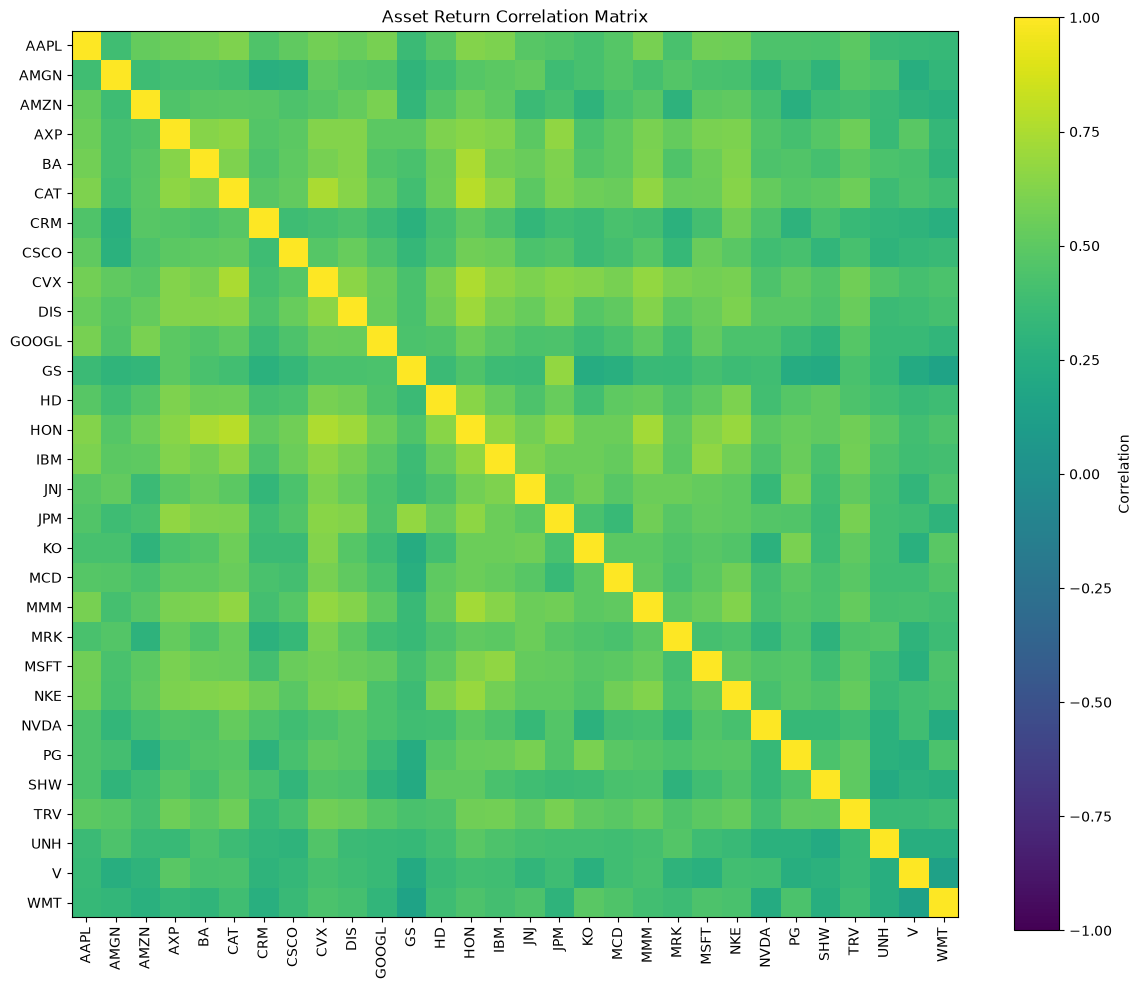

In [12]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 10))

im = ax.imshow(
    corr_matrix.values,
    vmin=-1,
    vmax=1
)

ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.index)))

ax.set_xticklabels(
    corr_matrix.columns,
    rotation=90
)

ax.set_yticklabels(
    corr_matrix.index
)

fig.colorbar(im, ax=ax, label="Correlation")

ax.set_title("Asset Return Correlation Matrix")

plt.tight_layout()
plt.show()

In [13]:
upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

pairwise_corr = upper_triangle.stack()

print(pairwise_corr.describe())

count    435.000000
mean       0.460994
std        0.108588
min        0.142235
25%        0.387329
50%        0.455150
75%        0.533225
max        0.786418
dtype: float64


In [14]:
print("Mean pairwise correlation:", pairwise_corr.mean())
print("Minimum pairwise correlation:", pairwise_corr.min())
print("Maximum pairwise correlation:", pairwise_corr.max())

print("\nLowest correlation pair:")
print(pairwise_corr.idxmin(), pairwise_corr.min())

print("\nHighest correlation pair:")
print(pairwise_corr.idxmax(), pairwise_corr.max())

Mean pairwise correlation: 0.4609936759721182
Minimum pairwise correlation: 0.142234523974025
Maximum pairwise correlation: 0.7864177493055116

Lowest correlation pair:
('V', 'WMT') 0.142234523974025

Highest correlation pair:
('CAT', 'HON') 0.7864177493055116


In [18]:
import numpy 
def minimum_weight_of_variance(cov):
    n=cov.shape[0]
    one_mat=np.ones(n)
    x=np.linalg.solve(cov,one_mat)
    w=x/(one_mat@x)
    return w
weight=minimum_weight_of_variance(corr_matrix)
weight    

array([ 0.00797988,  0.10198689,  0.09055291, -0.08525241,  0.05763311,
        0.01656482,  0.0983799 ,  0.10070639, -0.08314971, -0.04060091,
        0.00976605,  0.19961637,  0.02516112, -0.23567531, -0.07330594,
       -0.03944266, -0.02839928,  0.07318017, -0.03626558,  0.05184407,
        0.08251921,  0.0077989 , -0.04502012,  0.06180616,  0.08945013,
        0.15313416, -0.03498544,  0.10562616,  0.18248289,  0.18590806])

In [19]:
weight.sum()

np.float64(0.9999999999999999)

In [21]:
len(weight)

30

In [25]:
portfolio_var = weight @ corr_matrix @ weight
portfolio_var #positive definite

np.float64(0.3216978473967733)